<a href="https://colab.research.google.com/github/orenlevis/HiggsPeak_StatsProject/blob/main/Analysis_and_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# combine real data into a datafrme, drop any invalid ("NA") values.
df_data = pd.read_csv('data/Combined_mass_data_final.csv').dropna()

m4l = df_data["m_4l"].values
print(df_data.head())
print(len(m4l))

        m_4l
0  218.56589
1  140.45146
2  138.78133
3  272.18286
5  224.29002
9630


In [ ]:
import numpy as np

# histogram raw data near the suspected Higgs region only
m4l = m4l[(m4l > 100) & (m4l < 140)]
hist, bins = np.histogram(m4l, bins=50)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

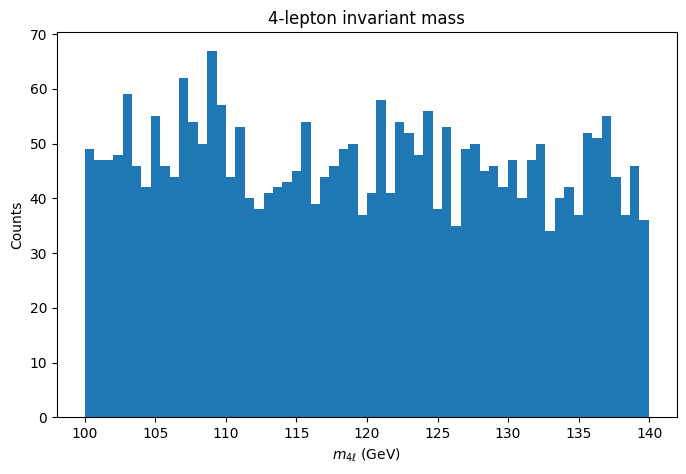

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(m4l, bins=60)

plt.xlabel(r"$m_{4 \ell}$ (GeV)")
plt.ylabel("Counts")
plt.title("4-lepton invariant mass")
plt.show()

In [ ]:
!pip install emcee
import emcee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.0 MB/s eta 0:00:00


In [ ]:
def model(x, mH, sigma, A, B0, k):
    signal = A * np.exp(-0.5 * ((x - mH) / sigma) ** 2)
    background = B0 * np.exp(-k * x)
    return signal + background

# PRIORS
# see report for justification
def log_prior(theta):
    mH, sigma, A, B0, k = theta
    if (120 < mH < 130) and (1.0 < sigma < 2.0) and (0 < A < 5000) and (0 < B0 < 100000) and (0 < k < 0.2):
        return 0.0
    return -np.inf


# POISSON LOG-LIKELIHOOD
def log_likelihood(theta, x, y):
    y_model = model(x, *theta)

    if np.any(y_model <= 0):
        return -np.inf

    # can have an additive constant
    return np.sum(y * np.log(y_model) - y_model)

# LOG POSTERIOR
def log_posterior(theta, x, y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, x, y)
    return lp + ll


In [ ]:
#MCMC code

ndim = 5  # number of parameters in the model
nwalkers = 30  # number of MCMC walkers
burn = 1000  # "burn-in" period to let chains stabilize
nsteps = 5000  # number of MCMC steps each walker takes

# initialize theta close to "expected" values
np.random.seed(0)
initial = np.array([125.0, 2.0, 100.0, 15000.0, 0.01])

pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

# use the Higgs region data only
m4l_window = m4l[(m4l >= 100) & (m4l <= 140)]

# histogram the data and sample
counts, bins = np.histogram(m4l_window, bins=20, range=(100, 140))
bin_centers = 0.5 * (bins[1:] + bins[:-1])

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[bin_centers, counts])
sampler.run_mcmc(pos, nsteps)

# sampler.chain is of shape (nwalkers, nsteps, ndim)
# throw-out the burn-in points and reshape
emcee_trace  = sampler.chain[:, burn:, :].reshape(-1, ndim)

print("done")

/usr/local/lib/python3.12/dist-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


done


In [ ]:
print(sampler.chain.shape) #original chain
print(emcee_trace.shape) #burned and flattened chain

(30, 5000, 5)
(120000, 5)


In [ ]:
labels = ["mH", "sigma", "fsig", "k"]

# get positive and negative uncertainties (distance of median to 84th and 16th
# percentile) respectively

for i, label in enumerate(labels):
    q16, q50, q84 = np.percentile(emcee_trace[:, i], [16, 50, 84])
    print(f"{label} = {q50:.4f} +{q84-q50:.4f} -{q50-q16:.4f}")

mH = 123.8043 +2.2505 -1.5330
sigma = 1.4633 +0.3536 -0.3236
fsig = 15.2069 +12.7425 -9.8137
k = 244.0695 +52.6650 -42.6533


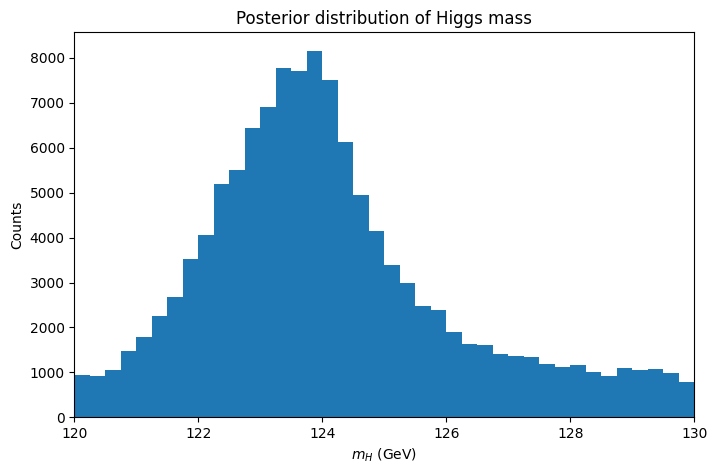

In [ ]:
# extract values from mcmc samples

mH_samples = emcee_trace[:, 0]
sigma_samples = emcee_trace[:, 1]
A_samples = emcee_trace[:, 2]

# histogram

plt.figure(figsize=(8,5))
plt.hist(mH_samples, bins=40)
plt.xlim(120,130)
plt.xlabel("$m_H$ (GeV)")
plt.ylabel("Counts")
plt.title("Posterior distribution of Higgs mass")
plt.show()

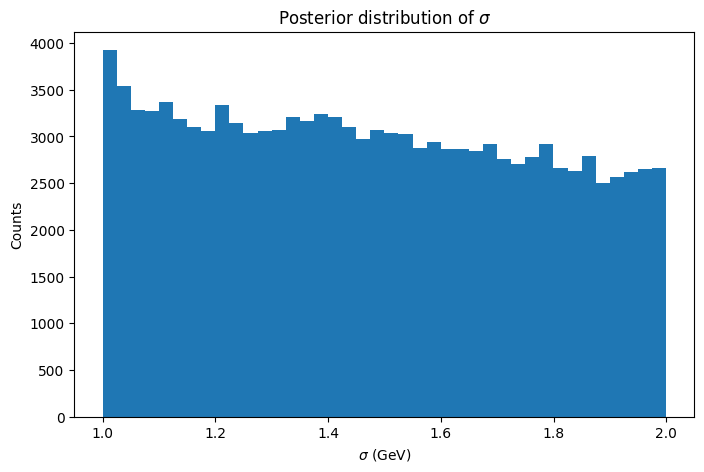

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(sigma_samples, bins=40)

plt.xlabel(r"$\sigma$ (GeV)")
plt.ylabel("Counts")
plt.title(r"Posterior distribution of $\sigma$")
plt.show()

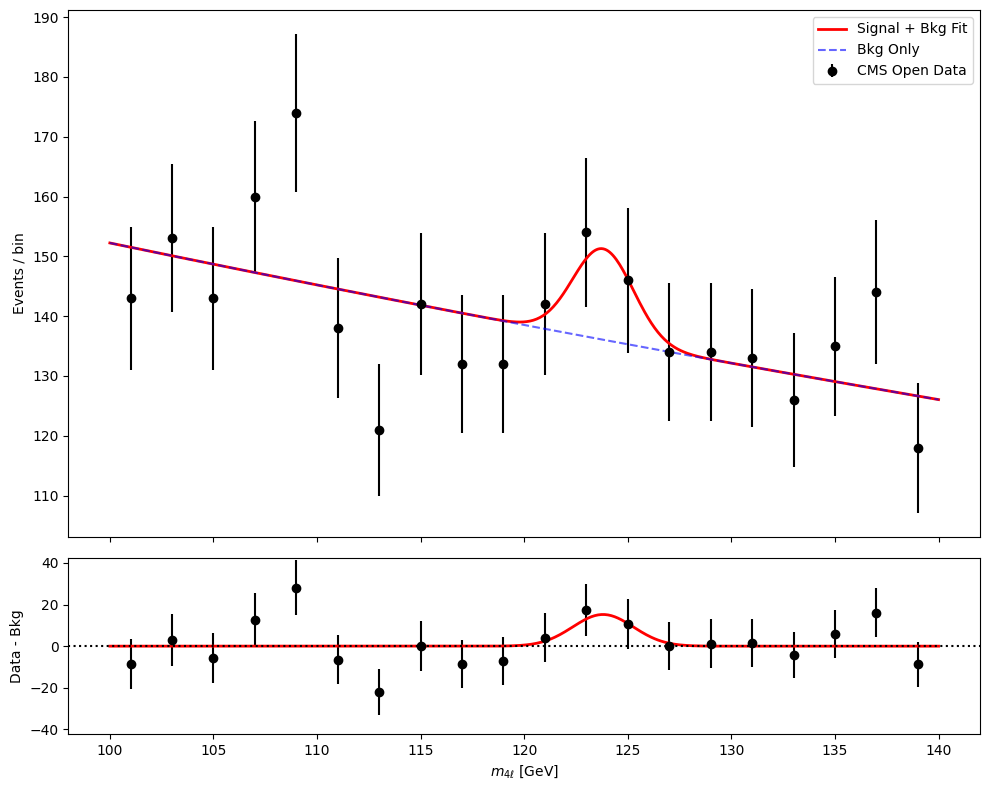

In [ ]:
# fit experimental data

theta_med = np.median(emcee_trace, axis=0)
mH_f, sigma_f, A_f, B0_f, k_f = theta_med

# define the components
x_range = np.linspace(100, 140, 500)
full_model = model(x_range, *theta_med)
bkg_only = B0_f * np.exp(-k_f * x_range)

# plot the data
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True,
                               gridspec_kw={'height_ratios': [3, 1]})

# full spectrum
ax1.errorbar(bin_centers, counts, yerr=np.sqrt(counts), fmt='ko', label="CMS Open Data")
ax1.plot(x_range, full_model, 'r-', lw=2, label="Signal + Bkg Fit")
ax1.plot(x_range, bkg_only, 'b--', alpha=0.6, label="Bkg Only")
ax1.set_ylabel("Events / bin")
ax1.legend()

# residuals
residual_counts = counts - (B0_f * np.exp(-k_f * bin_centers))
ax2.errorbar(bin_centers, residual_counts, yerr=np.sqrt(counts), fmt='ko')
ax2.plot(x_range, A_f * np.exp(-0.5 * ((x_range - mH_f) / sigma_f) ** 2), 'r-', lw=2)
ax2.axhline(0, color='black', linestyle=':')
ax2.set_xlabel(r"$m_{4\ell}$ [GeV]")
ax2.set_ylabel("Data - Bkg")
ax2.set_ylim(-max(residual_counts)*1.5, max(residual_counts)*1.5)

plt.tight_layout()
plt.show()

The next three cells were only helpful in choosing correct priors for our model. They are not needed for the analysis of the processed data, but serve as a good test to see if our model so far produces good results. The code checks


*   If we get negative likelihoods
*   Whether the acceptance fraction is between 0.2-0.5
*   Whether the signal is strong enough

After the pre-MCMC tests are done, we check whether the walkers converged to specific values for the parameter estimates using the trace plot.



In [ ]:
m4l_filt = m4l[(m4l >= 100) & (m4l <= 140)]
counts, bins = np.histogram(m4l_filt, bins=20, range=(100, 140))
bin_centers = 0.5 * (bins[1:] + bins[:-1])

print(f"Data counts: {counts}")
print(f"Number of bins: {len(counts)}")
print(f"Bin centers length: {len(bin_centers)}")

# test likelihood once to see if we get -inf
test_theta = [125.0, 2.0, 2.0, 5.0, 0.01] # mH, sigma, A, B0, k
test_ll = log_likelihood(test_theta, bin_centers, counts)
print(f"Test Log-Likelihood: {test_ll}")

Data counts: [143 153 143 160 174 138 121 142 132 132 142 154 146 134 134 133 126 135
 144 118]
Number of bins: 20
Bin centers length: 20
Test Log-Likelihood: 1483.6739302789626


In [ ]:
# check accptance fraction

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[bin_centers, counts])
sampler.run_mcmc(pos, nsteps)
print("New mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

New mean acceptance fraction: 0.4336399999999999


Median Signal Amplitude: 15.21


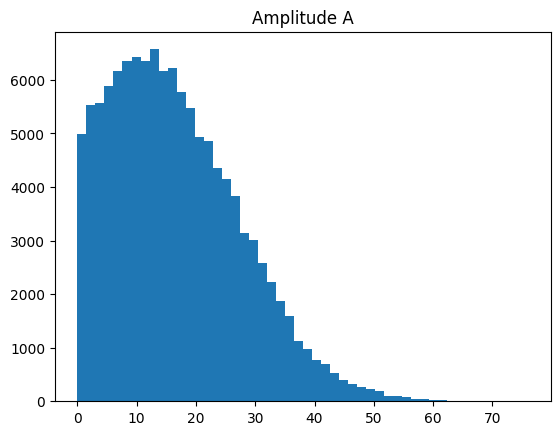

In [ ]:
# check the signal strength
A_samples = emcee_trace[:, 2]
print(f"Median Signal Amplitude: {np.median(A_samples):.2f}")

plt.hist(A_samples, bins=50)
plt.title("Amplitude A")
plt.show()

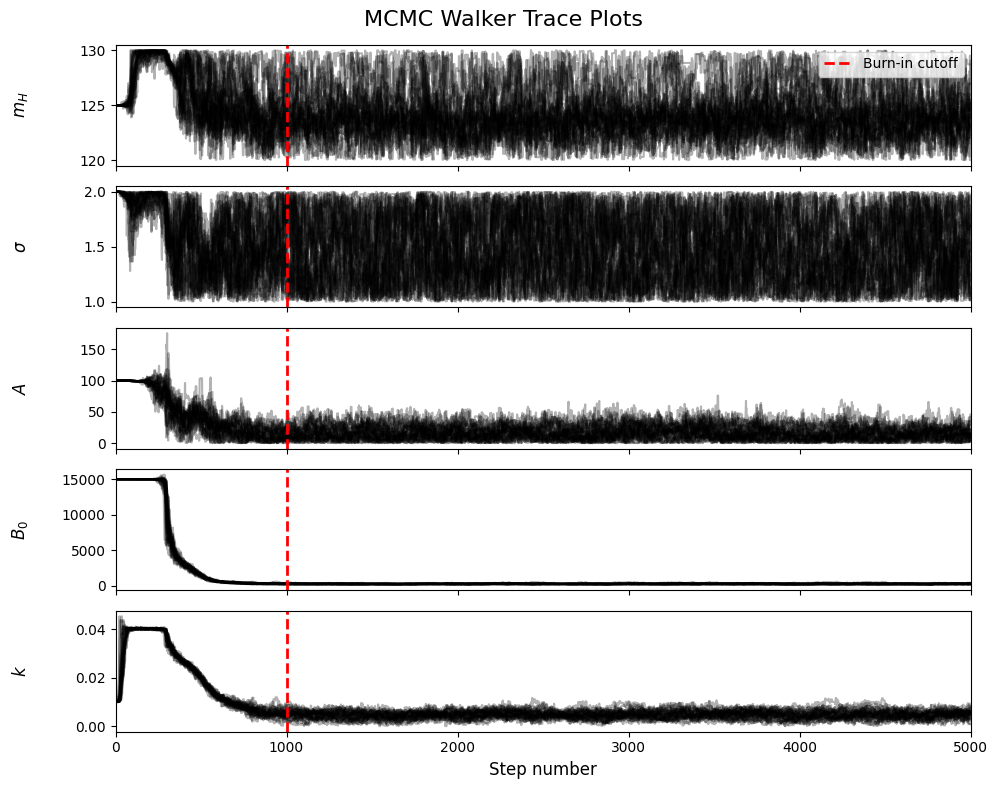

In [ ]:
# trace plot for convergence check

fig, axes = plt.subplots(ndim, figsize=(10, 8), sharex=True)
samples = sampler.get_chain() # get the raw, unburned chain
labels = [r"$m_H$", r"$\sigma$", r"$A$", r"$B_0$", r"$k$"]

for i in range(ndim):
    ax = axes[i]
    # plot all walkers for parameter i
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i], fontsize=12)
    ax.yaxis.set_label_coords(-0.1, 0.5)

    # burn-in cutoff point
    ax.axvline(burn, color='red', linestyle='--', lw=2, label='Burn-in cutoff' if i==0 else "")
    if i == 0:
        ax.legend(loc="upper right")

axes[-1].set_xlabel("Step number", fontsize=12)
plt.suptitle("MCMC Walker Trace Plots", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
!pip install corner
import corner

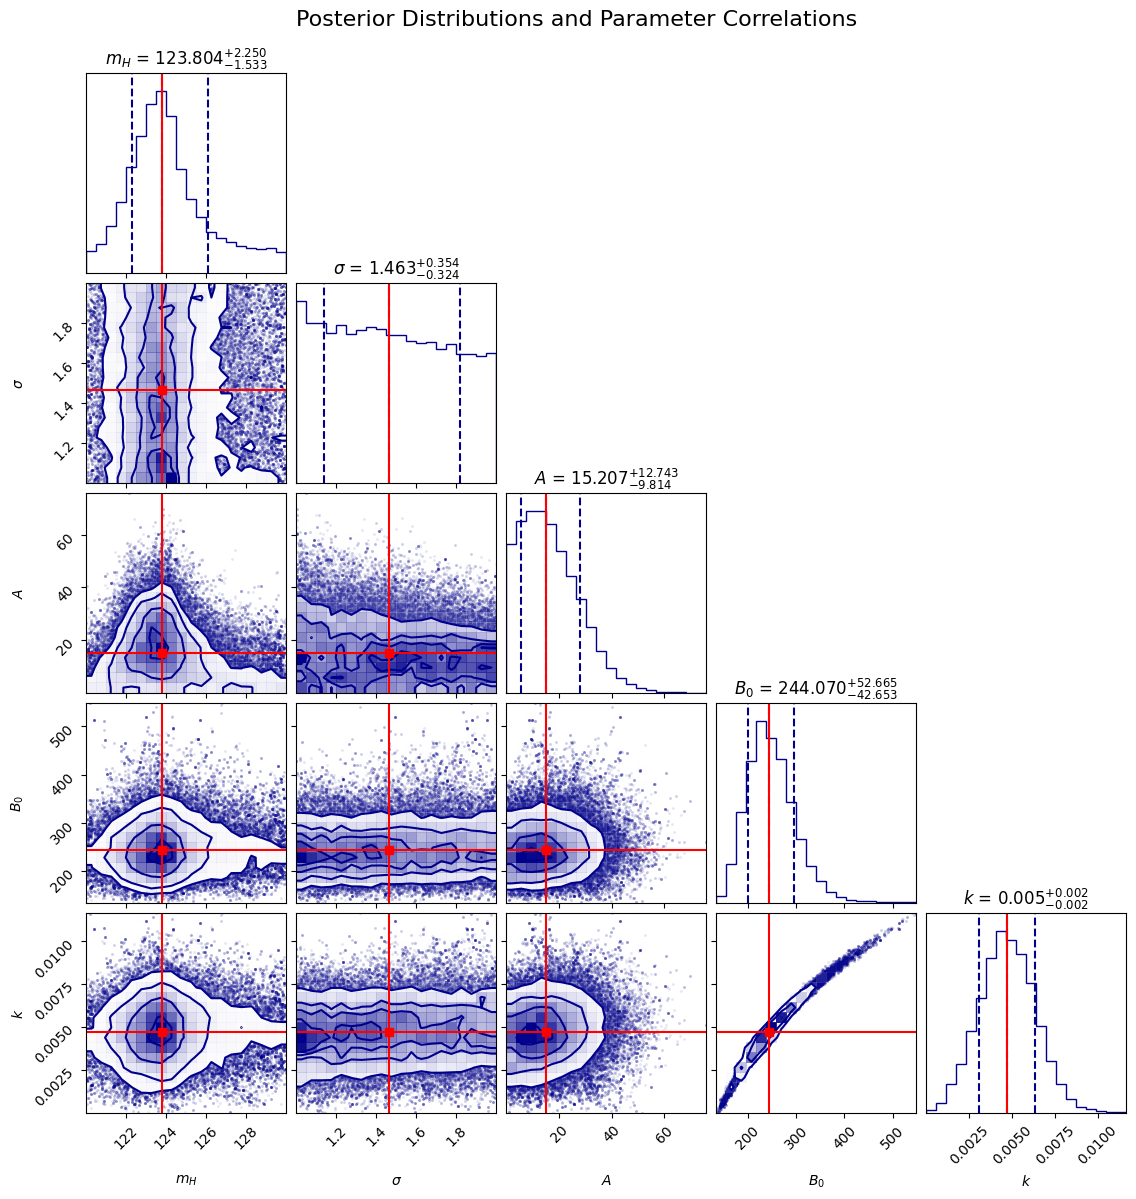

In [ ]:
# Corner plot
# use the 'emcee_trace' here because we only want the burned samples
theta_med = np.median(emcee_trace, axis=0)

fig = corner.corner(
    emcee_trace,
    labels=labels,
    truths=theta_med, # best-fit values
    quantiles=[0.16, 0.5, 0.84], # calculates the 1-sigma errors
    show_titles=True,
    title_kwargs={"fontsize": 12},
    color="darkblue",
    truth_color="red",
    title_fmt=".3f"
)

plt.suptitle("Posterior Distributions and Parameter Correlations", fontsize=16, y=1.02)
plt.show()

In [ ]:
print("Final Parameter Estimates (1-sigma errors)")
for i, label in enumerate(labels):
    q16, q50, q84 = np.percentile(emcee_trace[:, i], [16, 50, 84])
    # note the asymmetrical error: + (84th - 50th) and - (50th - 16th)
    upper_err = q84 - q50
    lower_err = q50 - q16
    print(f"{label}: {q50:.3f}  (+{upper_err:.3f} / -{lower_err:.3f})")

Final Parameter Estimates (1-sigma errors)
$m_H$: 123.804  (+2.250 / -1.533)
$\sigma$: 1.463  (+0.354 / -0.324)
$A$: 15.207  (+12.743 / -9.814)
$B_0$: 244.070  (+52.665 / -42.653)
$k$: 0.005  (+0.002 / -0.002)
